# Classificação Supervisionada com KMeans no Dataset Dry Bean (Balanceado)

Este notebook apresenta um pipeline didático e numerado para classificação supervisionada utilizando KMeans no dataset Dry Bean, com balanceamento das classes via oversampling. O objetivo é avaliar o impacto do balanceamento no desempenho do agrupamento multiclasse.

## 1. Importação das Bibliotecas

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score, confusion_matrix, mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.utils import resample
import os
import seaborn as sns
os.makedirs('img', exist_ok=True)

## 2. Carregamento e Balanceamento dos Dados

O dataset Dry Bean é carregado e as classes minoritárias são balanceadas por oversampling, igualando a quantidade de exemplos de todas as classes. Isso evita que o modelo favoreça as classes majoritárias.

Distribuição original das classes:
Class
DERMASON    3546
SIRA        2636
SEKER       2027
HOROZ       1928
CALI        1630
BARBUNYA    1322
BOMBAY       522
Name: count, dtype: int64
Distribuição após balanceamento:
Class
BARBUNYA    3546
CALI        3546
BOMBAY      3546
SIRA        3546
DERMASON    3546
SEKER       3546
HOROZ       3546
Name: count, dtype: int64


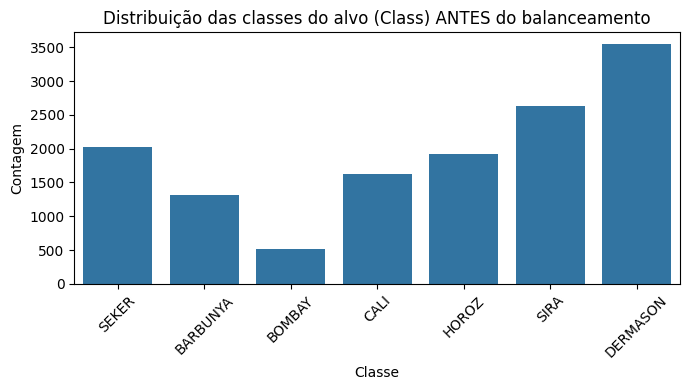

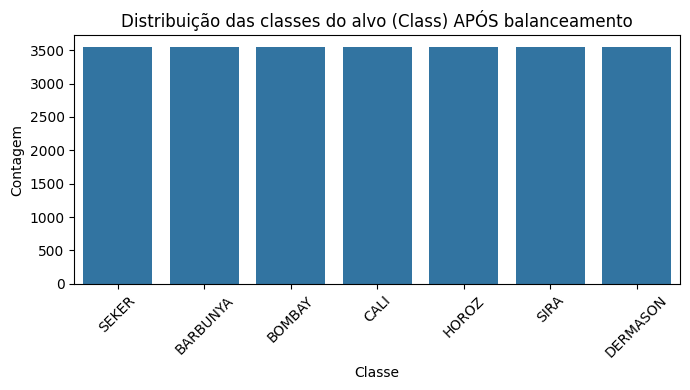

In [20]:
# Carregar o dataset Dry Bean
bean_df = pd.read_excel('data/DryBeanDataset/Dry_Bean_Dataset.xlsx')
bean_df = bean_df.dropna()

# Exibe distribuição original das classes
print('Distribuição original das classes:')
print(bean_df['Class'].value_counts())

# Balanceamento por oversampling (todas as classes terão o mesmo número de exemplos da classe majoritária)
max_count = bean_df['Class'].value_counts().max()
bean_df_balanced = pd.DataFrame()
for label in bean_df['Class'].unique():
    df_class = bean_df[bean_df['Class'] == label]
    df_upsampled = resample(df_class, replace=True, n_samples=max_count, random_state=42)
    bean_df_balanced = pd.concat([bean_df_balanced, df_upsampled])
bean_df_balanced = bean_df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

# Exibe distribuição após balanceamento
print('Distribuição após balanceamento:')
print(bean_df_balanced['Class'].value_counts())

# Visualizar frequência das classes do alvo antes do balanceamento
plt.figure(figsize=(7,4))
class_names = bean_df['Class'].unique()
sns.countplot(x=bean_df['Class'])
plt.title('Distribuição das classes do alvo (Class) ANTES do balanceamento')
plt.xlabel('Classe')
plt.ylabel('Contagem')
plt.xticks(ticks=range(len(class_names)), labels=class_names, rotation=45)
plt.tight_layout()
plt.savefig('img/kmeans_drybean_class_distribution.png')
plt.show()

# Codificar variáveis categóricas
for col in bean_df_balanced.select_dtypes(include='object').columns:
    bean_df_balanced[col] = LabelEncoder().fit_transform(bean_df_balanced[col].astype(str))

# Separar features e alvo
X = bean_df_balanced.drop('Class', axis=1).values
y = bean_df_balanced['Class'].values  # Multiclasse

# Normalizar os dados
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Visualizar frequência das classes do alvo após o balanceamento
plt.figure(figsize=(7,4))
class_names = bean_df['Class'].unique()
sns.countplot(x=bean_df_balanced['Class'])
plt.title('Distribuição das classes do alvo (Class) APÓS balanceamento')
plt.xlabel('Classe')
plt.ylabel('Contagem')
plt.xticks(ticks=range(len(class_names)), labels=class_names, rotation=45)
plt.tight_layout()
plt.savefig('img/kmeans_drybean_balance_class_distribution.png')
plt.show()

## 3. Pré-processamento dos Dados

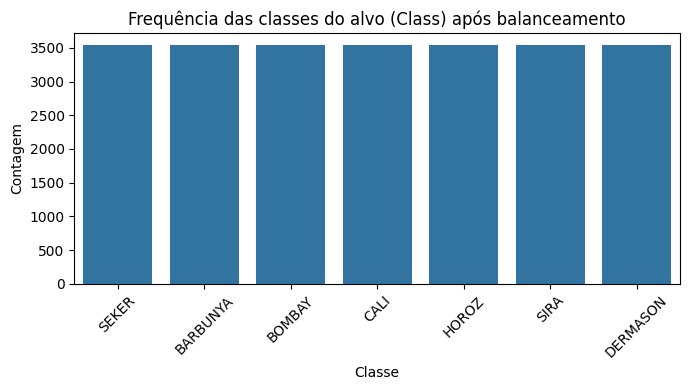

In [21]:
# Codificar variáveis categóricas
for col in bean_df_balanced.select_dtypes(include='object').columns:
    bean_df_balanced[col] = LabelEncoder().fit_transform(bean_df_balanced[col].astype(str))

# Separar features e alvo
X = bean_df_balanced.drop('Class', axis=1).values
y = bean_df_balanced['Class'].values  # Multiclasse

# Normalizar os dados
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Visualizar frequência das classes do alvo
plt.figure(figsize=(7,4))
class_names = bean_df['Class'].unique()
sns.countplot(x=bean_df_balanced['Class'])
plt.title('Frequência das classes do alvo (Class) após balanceamento')
plt.xlabel('Classe')
plt.ylabel('Contagem')
plt.xticks(ticks=range(len(class_names)), labels=class_names, rotation=45)
plt.tight_layout()
plt.show()

## 4. Divisão em Treino/Teste

In [22]:
# Divisão dos dados em treino e teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y)

## 5. Definição do Número de Clusters

In [23]:
n_clusters = 7  # Definido pelo método do cotovelo (número de classes)

## 6. Implementação do KMeans Supervisionado

In [24]:
class KMeansSupervisionado:
    def __init__(self, n_clusters, random_state=0):
        self.n_clusters = n_clusters
        self.random_state = random_state
        self.kmeans = KMeans(n_clusters=n_clusters, random_state=random_state)
        self.cluster_labels_ = None

    def fit(self, X, y):
        clusters = self.kmeans.fit_predict(X)
        self.cluster_labels_ = []
        for i in range(self.n_clusters):
            mask = (clusters == i)
            if np.any(mask):
                label = np.bincount(y[mask]).argmax()
            else:
                label = -1
            self.cluster_labels_.append(label)

    def predict(self, X):
        clusters = self.kmeans.predict(X)
        return np.array([self.cluster_labels_[c] for c in clusters])

    def evaluate(self, X, y_true):
        y_pred = self.predict(X)
        acc = accuracy_score(y_true, y_pred)
        cm = confusion_matrix(y_true, y_pred)
        return acc, cm

## 7. Treinamento e Avaliação Inicial

Acurácia: 0.7794
Matriz de Confusão:
[[ 945    0   70    0    6   17   25]
 [   0 1064    0    0    0    0    0]
 [  84    0  948    0   21    0   11]
 [   6    0    0    0    3  125  930]
 [   1    0  156    0  894    0   13]
 [   9    0    0    0    0  985   70]
 [   9    0   47    0   29   11  968]]


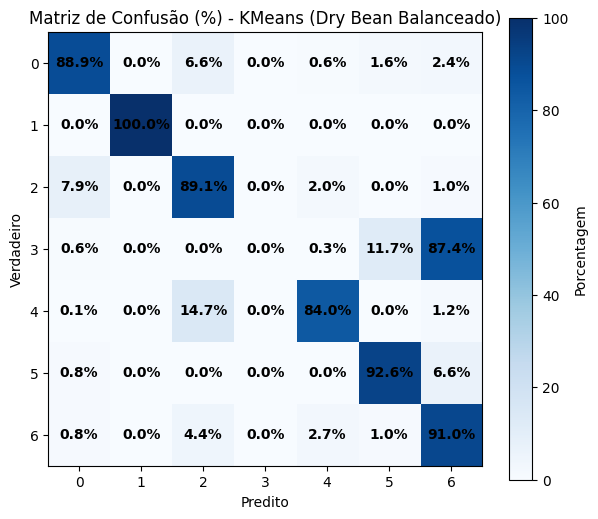

In [25]:
clf = KMeansSupervisionado(n_clusters=n_clusters, random_state=42)
clf.fit(X_train, y_train)
acc, cm = clf.evaluate(X_test, y_test)
print(f'Acurácia: {acc:.4f}')
print('Matriz de Confusão:')
print(cm)

plt.figure(figsize=(7,6))
cm_percent = cm / cm.sum(axis=1, keepdims=True) * 100
plt.imshow(cm_percent, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Matriz de Confusão (%) - KMeans (Dry Bean Balanceado)')
plt.colorbar(label='Porcentagem')
plt.ylabel('Verdadeiro')
plt.xlabel('Predito')
for i in range(cm_percent.shape[0]):
    for j in range(cm_percent.shape[1]):
        plt.text(j, i, f'{cm_percent[i, j]:.1f}%', ha='center', va='center', color='black', fontsize=10, fontweight='bold')
plt.savefig('img/kmeans_drybean_balance_confusion_matrix.png')
plt.show()

## 8. Visualização dos Agrupamentos com PCA

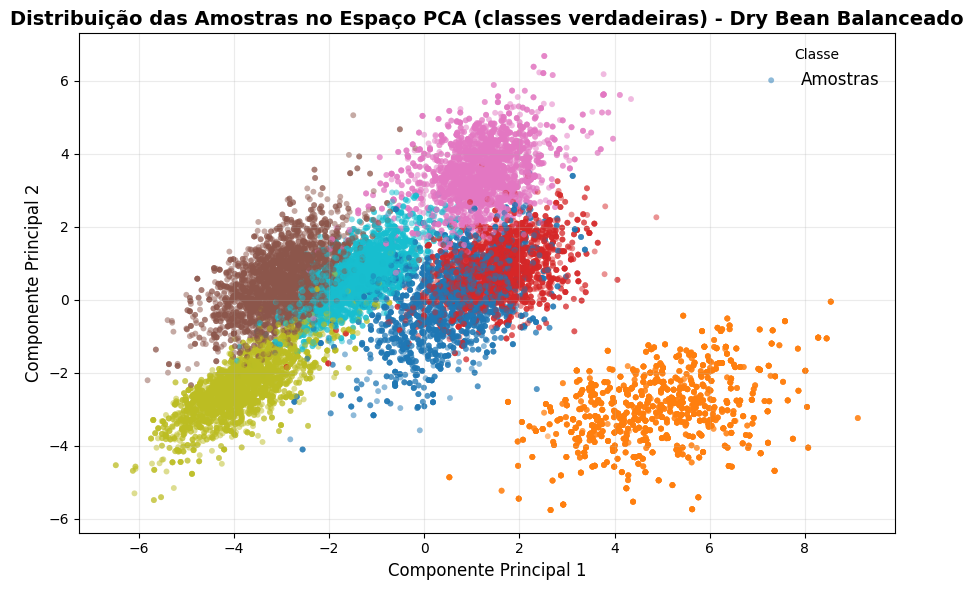

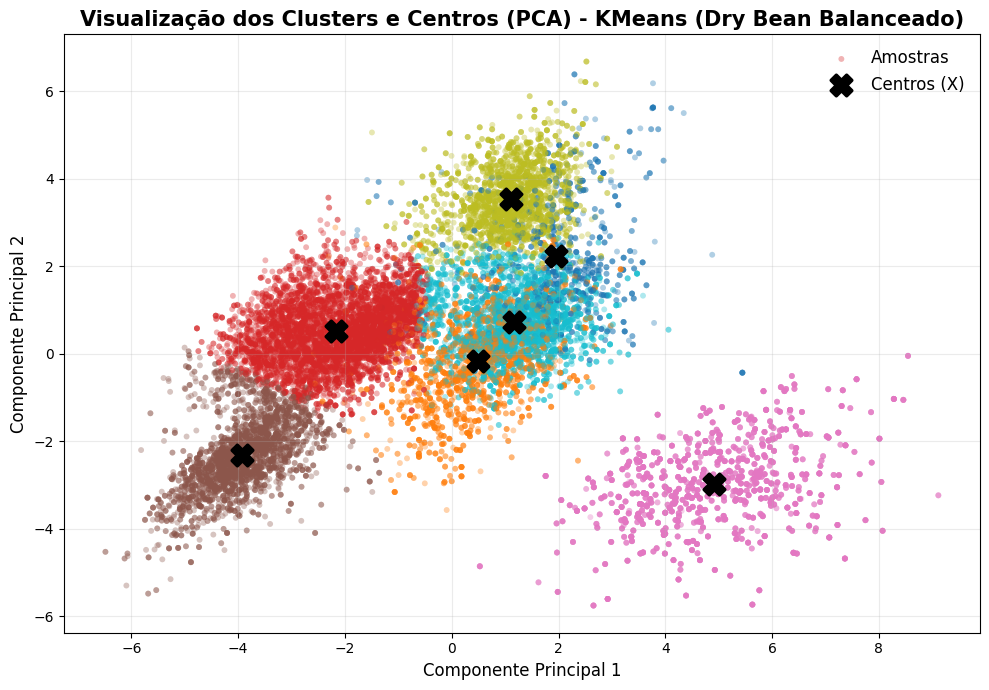

In [26]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# Visualização dos dados no espaço 2D do PCA, colorindo pelas classes verdadeiras
plt.figure(figsize=(9,6))
plt.scatter(
    X_pca[:,0], X_pca[:,1], 
    c=y, cmap='tab10', alpha=0.5, s=18, edgecolor='none', label='Amostras'
    )
plt.title('Distribuição das Amostras no Espaço PCA (classes verdadeiras) - Dry Bean Balanceado', fontsize=14, fontweight='bold')
plt.xlabel('Componente Principal 1', fontsize=12)
plt.ylabel('Componente Principal 2', fontsize=12)
plt.grid(alpha=0.25)
plt.legend(title='Classe', frameon=False, fontsize=12, loc='best')
plt.tight_layout()
plt.savefig('img/kmeans_drybean_balance_pca_true_labels.png', dpi=150)
plt.show()

# Clustering e visualização dos clusters e centros no PCA
cls = KMeans(n_clusters=n_clusters, random_state=42)
clusters = cls.fit_predict(X)
centros = cls.cluster_centers_
centros_pca = pca.transform(centros)

plt.figure(figsize=(10,7))
plt.scatter(
    X_pca[:,0], X_pca[:,1], 
    c=clusters, cmap='tab10', alpha=0.35, s=18, edgecolor='none', label='Amostras'
    )
plt.scatter(
    centros_pca[:,0], centros_pca[:,1], 
    c='black', marker='X', s=220, linewidths=2.5, zorder=4, label='Centros (X)'
    )
plt.title('Visualização dos Clusters e Centros (PCA) - KMeans (Dry Bean Balanceado)', fontsize=15, fontweight='bold')
plt.xlabel('Componente Principal 1', fontsize=12)
plt.ylabel('Componente Principal 2', fontsize=12)
plt.grid(alpha=0.25)
plt.legend(frameon=False, fontsize=12, loc='best')
plt.tight_layout()
plt.savefig('img/kmeans_drybean_balance_clusters_pca.png', dpi=150)
plt.show()

## 9. Repetição dos Experimentos e Análise Quantitativa

Execução do experimento múltiplas vezes com diferentes seeds, cálculo de métricas agregadas (média, desvio padrão, matriz de confusão média, precisão, recall, F1-score) e geração de gráficos para análise de robustez. Todos os resultados são salvos para análise posterior.

MSE médio: 1.8764
Desvio padrão do MSE: 0.2840
Acurácia média: 0.7537
Desvio padrão da acurácia: 0.0448
Acurácia global: 0.7537
Precisão (macro): 0.7555
Recall (macro): 0.7537
F1-score (macro): 0.7532
Matriz de Confusão Média:
[[ 879    0  117   12   11   12   33]
 [   1 1061    2    0    0    0    0]
 [ 340    0  667    2   41    3   11]
 [   2    0    4  540    3   89  425]
 [   9    0  143    6  889    0   17]
 [   7    0    1   54    0  969   34]
 [  14    0   44  362   28    9  608]]


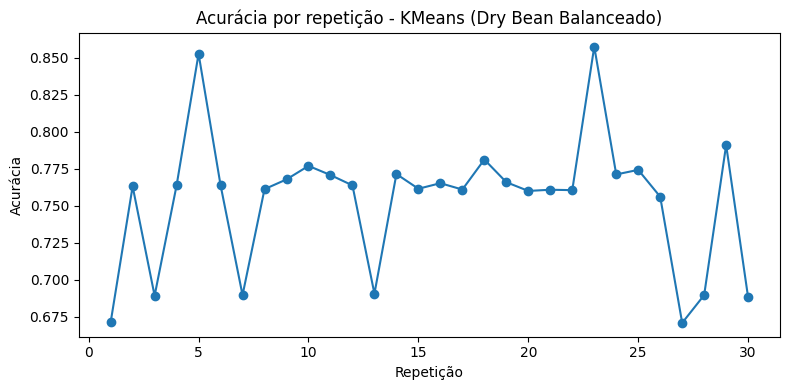

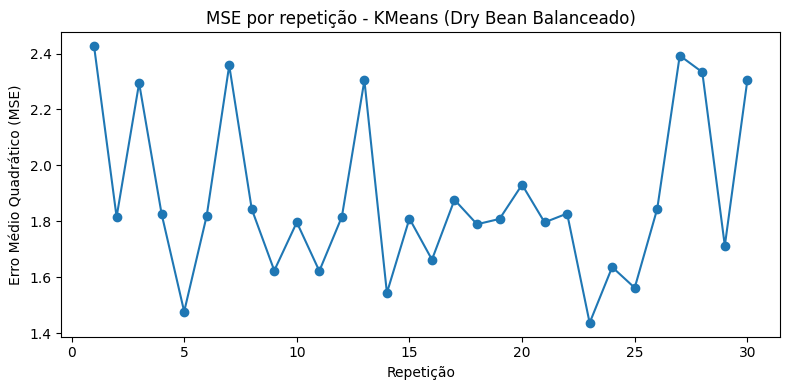

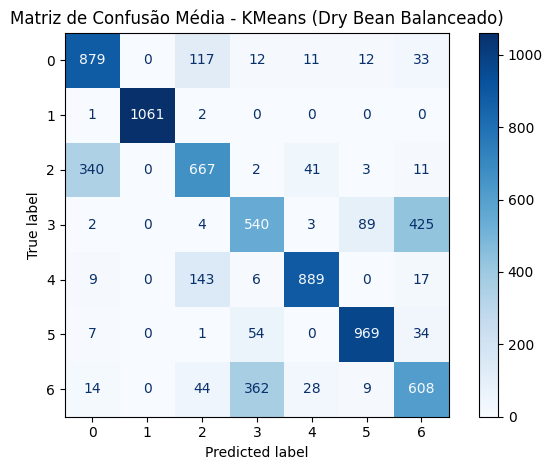

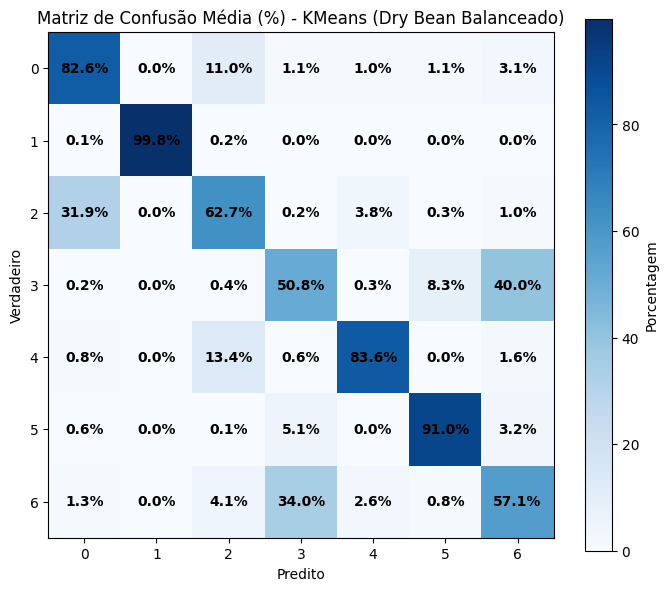

A matriz de confusão média não é 2x2. Não é possível calcular as métricas binárias.


In [27]:
# ===============================
# 9. Repetição dos Experimentos e Análise Quantitativa (KMeans - Dry Bean Balanceado)
# ===============================
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

n_repeats = 30
acuracias = []
mse_list = []
matrizes_confusao = []
y_true_all = []
y_pred_all = []

for seed in range(1, n_repeats+1):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=seed, stratify=y)
    clf = KMeansSupervisionado(n_clusters=n_clusters, random_state=seed)
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    acuracias.append(acc)
    mse_list.append(mse)
    matrizes_confusao.append(confusion_matrix(y_test, y_pred))
    y_true_all.extend(y_test)
    y_pred_all.extend(y_pred)

# Conversão para numpy arrays
acuracias = np.array(acuracias)
mse_array = np.array(mse_list)
matrizes_confusao = np.array(matrizes_confusao)

# Estatísticas globais
mse_medio = mse_array.mean()
mse_std = mse_array.std()
acc_medio = acuracias.mean()
acc_std = acuracias.std()

# Matriz de confusão média (inteira)
matriz_confusao_media = np.mean(matrizes_confusao, axis=0)
matriz_confusao_media_int = np.round(matriz_confusao_media).astype(int)

# Métricas macro globais
prec = precision_score(y_true_all, y_pred_all, average='macro')
rec = recall_score(y_true_all, y_pred_all, average='macro')
f1 = f1_score(y_true_all, y_pred_all, average='macro')

print(f'MSE médio: {mse_medio:.4f}')
print(f'Desvio padrão do MSE: {mse_std:.4f}')
print(f'Acurácia média: {acc_medio:.4f}')
print(f'Desvio padrão da acurácia: {acc_std:.4f}')
print(f"Acurácia global: {acc_medio:.4f}")
print(f"Precisão (macro): {prec:.4f}")
print(f"Recall (macro): {rec:.4f}")
print(f"F1-score (macro): {f1:.4f}")
print("Matriz de Confusão Média:")
print(matriz_confusao_media_int)

# Gráfico de acurácia por repetição
plt.figure(figsize=(8,4))
plt.plot(range(1, n_repeats+1), acuracias, marker='o')
plt.xlabel('Repetição')
plt.ylabel('Acurácia')
plt.title('Acurácia por repetição - KMeans (Dry Bean Balanceado)')
plt.tight_layout()
plt.savefig('img/kmeans_drybean_balance_accuracy_repetitions.png')
plt.show()

# Gráfico de MSE por repetição
plt.figure(figsize=(8,4))
plt.plot(range(1, n_repeats+1), mse_array, marker='o')
plt.xlabel('Repetição')
plt.ylabel('Erro Médio Quadrático (MSE)')
plt.title('MSE por repetição - KMeans (Dry Bean Balanceado)')
plt.tight_layout()
plt.savefig('img/kmeans_drybean_balance_mse_repetitions.png')
plt.show()

# Visualização da matriz de confusão média
disp = ConfusionMatrixDisplay(confusion_matrix=matriz_confusao_media_int)
disp.plot(cmap='Blues')
plt.title('Matriz de Confusão Média - KMeans (Dry Bean Balanceado)')
plt.tight_layout()
plt.savefig('img/kmeans_drybean_balance_confusion_matrix_media.png')
plt.show()

# Visualização da matriz de confusão média em porcentagem
cm_percent = matriz_confusao_media / matriz_confusao_media.sum(axis=1, keepdims=True) * 100
plt.figure(figsize=(7,6))
plt.imshow(cm_percent, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Matriz de Confusão Média (%) - KMeans (Dry Bean Balanceado)')
plt.colorbar(label='Porcentagem')
plt.ylabel('Verdadeiro')
plt.xlabel('Predito')
for i in range(cm_percent.shape[0]):
    for j in range(cm_percent.shape[1]):
        plt.text(j, i, f'{cm_percent[i, j]:.1f}%', ha='center', va='center', color='black', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.savefig('img/kmeans_drybean_balance_confusion_matrix_media_percent.png')
plt.show()

# Salvar resultados para análise posterior
np.save('img/kmeans_drybean_balance_accuracies.npy', acuracias)
np.savetxt('img/kmeans_drybean_balance_accuracies.csv', acuracias, delimiter=',')
np.save('img/kmeans_drybean_balance_mse_repetitions.npy', mse_array)
np.savetxt('img/kmeans_drybean_balance_mse_repetitions.csv', mse_array, delimiter=',')
np.save('img/kmeans_drybean_balance_confusion_matrix_media.npy', matriz_confusao_media)
np.savetxt('img/kmeans_drybean_balance_confusion_matrix_media.csv', matriz_confusao_media, delimiter=',')

# Cálculo detalhado das métricas binárias (apenas para problemas 2x2)
if matriz_confusao_media_int.shape == (2, 2):
    TN, FP, FN, TP = matriz_confusao_media_int[0,0], matriz_confusao_media_int[0,1], matriz_confusao_media_int[1,0], matriz_confusao_media_int[1,1]
    total = TN + FP + FN + TP
    acuracia = (TP + TN) / total if total > 0 else 0
    precisao = TP / (TP + FP) if (TP + FP) > 0 else 0
    revocacao = TP / (TP + FN) if (TP + FN) > 0 else 0
    especificidade = TN / (TN + FP) if (TN + FP) > 0 else 0
    f1_bin = 2 * (precisao * revocacao) / (precisao + revocacao) if (precisao + revocacao) > 0 else 0

    print(f'Acurácia (binária): {acuracia:.4f}')
    print(f'Precisão (binária): {precisao:.4f}')
    print(f'Revocação (Recall, binária): {revocacao:.4f}')
    print(f'Especificidade: {especificidade:.4f}')
    print(f'F1-Score (binária): {f1_bin:.4f}')
    print(f'TN: {TN}, FP: {FP}, FN: {FN}, TP: {TP}')
else:
    print("A matriz de confusão média não é 2x2. Não é possível calcular as métricas binárias.")